<a href="https://colab.research.google.com/github/AnkaRezaa/machine_learning_254107023002/blob/main/JS04/Tugas_Praktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tugas Praktikum


1. Tugas K-Means

Buatlah sebuah model K-Means dengan ketentuan,

1. Gunakan data 'Mall_Customers.csv'

2. Tentukan fitur apa yang tepat untuk melakukan clustering (minimal 2)

3. Buatlah model K-Means dengan mempertimbangkan jumlah
k
k yang terbaik.

Tugas 1: K-Means Clustering (Mall_Customers.csv)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv('Mall_Customers.csv')

In [3]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

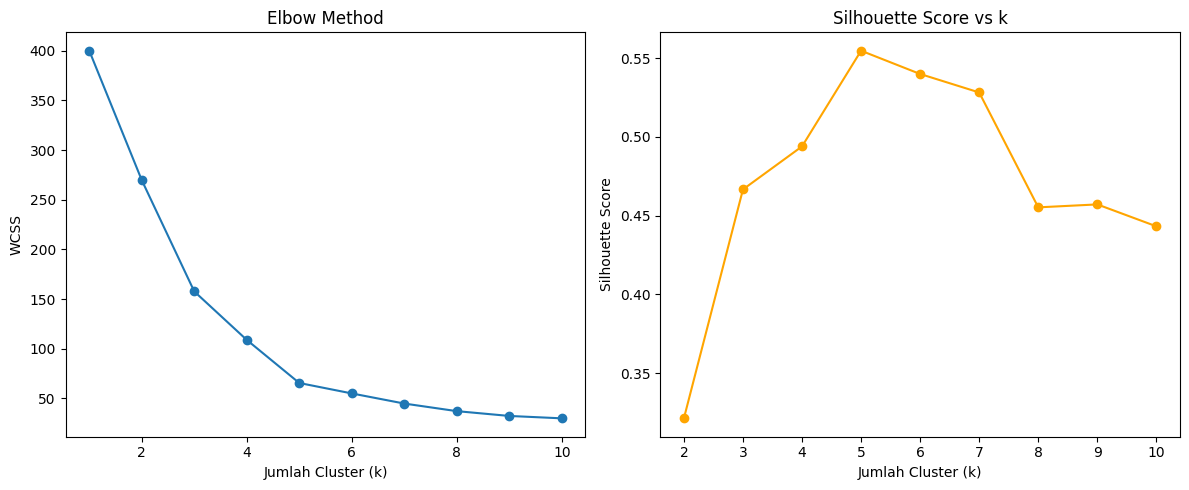

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 11), [KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10).fit(X_scaled).inertia_ for i in range(1, 11)], marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Score vs k')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [7]:
best_k = 5
kmeans_final = KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans_final.fit_predict(X_scaled)

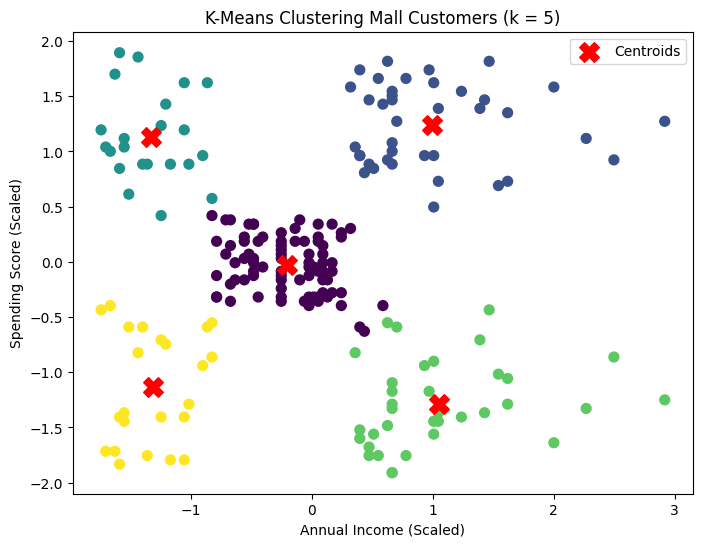

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, cmap='viridis', s=50)
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.title(f'K-Means Clustering Mall Customers (k = {best_k})')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.legend()
plt.show()

Tugas 2: DBSCAN (make_moons) & Eksperimen Hyperparameter

Kode Utama DBSCAN

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

In [11]:
X_moons, y_true = make_moons(n_samples=1000, noise=0.05, random_state=42)
X_moons_scaled = StandardScaler().fit_transform(X_moons)

In [12]:
db = DBSCAN(eps=0.2, min_samples=5).fit(X_moons_scaled)
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"Jumlah Klaster : {n_clusters_}")
print(f"Jumlah Noise   : {n_noise_}")

Jumlah Klaster : 2
Jumlah Noise   : 0


In [13]:
print("\n=== Metrik Evaluasi ===")
print(f"Homogeneity                 : {metrics.homogeneity_score(y_true, labels):.3f}")
print(f"Completeness                : {metrics.completeness_score(y_true, labels):.3f}")
print(f"V-measure                   : {metrics.v_measure_score(y_true, labels):.3f}")
print(f"Adjusted Rand Index (ARI)   : {metrics.adjusted_rand_score(y_true, labels):.3f}")
print(f"Adjusted Mutual Info (AMI)  : {metrics.adjusted_mutual_info_score(y_true, labels):.3f}")
print(f"Silhouette Coefficient      : {metrics.silhouette_score(X_moons_scaled, labels):.3f}")


=== Metrik Evaluasi ===
Homogeneity                 : 1.000
Completeness                : 1.000
V-measure                   : 1.000
Adjusted Rand Index (ARI)   : 1.000
Adjusted Mutual Info (AMI)  : 1.000
Silhouette Coefficient      : 0.391


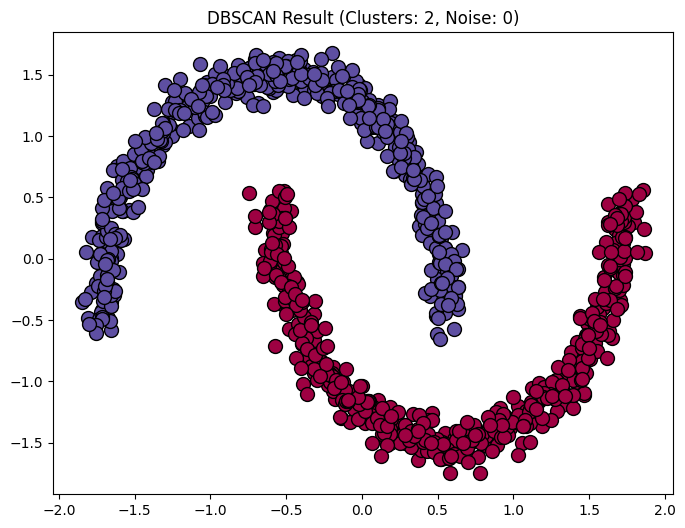

In [14]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(8, 6))
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # Hitam untuk Noise

    class_member_mask = (labels == k)

    # Core samples = titik besar (markersize 10)
    xy = X_moons_scaled[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=10)

    # Non-core / Border samples = titik kecil (markersize 4)
    xy = X_moons_scaled[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=4)

plt.title(f'DBSCAN Result (Clusters: {n_clusters_}, Noise: {n_noise_})')
plt.show()

Eksperimen Hyperparameter (Tabel Pencatatan)

In [15]:
eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

results = []

for eps in eps_values:
    for min_s in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=min_s).fit(X_moons_scaled)
        lbls = model.labels_

        n_c = len(set(lbls)) - (1 if -1 in lbls else 0)
        n_n = list(lbls).count(-1)

        # Silhouette hanya bisa dihitung jika terdapat > 1 klaster dan < seluruh sampel
        if n_c > 1 and n_c < len(X_moons_scaled):
            sil = metrics.silhouette_score(X_moons_scaled, lbls)
            ari = metrics.adjusted_rand_score(y_true, lbls)
            v_meas = metrics.v_measure_score(y_true, lbls)
        else:
            sil, ari, v_meas = np.nan, np.nan, np.nan

        results.append({
            'eps': eps,
            'min_samples': min_s,
            'Clusters': n_c,
            'Noise': n_n,
            'ARI': round(ari, 3) if not np.isnan(ari) else 'N/A',
            'V-Measure': round(v_meas, 3) if not np.isnan(v_meas) else 'N/A',
            'Silhouette': round(sil, 3) if not np.isnan(sil) else 'N/A'
        })

df_results = pd.DataFrame(results)
display(df_results)

,eps,min_samples,Clusters,Noise,ARI,V-Measure,Silhouette
0,0.05,3,69,186,0.03,0.257,0.113
1,0.05,10,3,970,0.002,0.049,-0.294
2,0.05,20,0,1000,N/A,N/A,N/A
3,0.10,3,2,14,0.972,0.943,0.252
4,0.10,10,7,57,0.523,0.571,0.162
5,0.10,20,6,850,0.017,0.155,-0.36
6,0.30,3,2,0,1.0,1.0,0.391
7,0.30,10,2,0,1.0,1.0,0.391
8,0.30,20,2,0,1.0,1.0,0.391
9,0.50,3,2,0,1.0,1.0,0.391
